# Teste Técnico - Cientista de Dados

## Previsão de Canal Aduaneiro

### Informações Gerais

    Tempo estimado: 4-6 horas
    Formato: Notebook Jupyter (.ipynb) ou scripts Python + relatório em Markdown
    Entrega: Repositório Git com código completo e documentação

## 1. Contexto do Problema
## Introdução

O canal aduaneiro é um sistema de classificação de risco utilizado pela Receita Federal para
determinar o nível de fiscalização aplicado a uma Declaração de Importação (DI). Existem quatro
tipos de canais:

    Verde: Sem fiscalização - liberação automática
    Amarelo: Fiscalização documental apenas
    Vermelho: Fiscalização documental e física
    Cinza: Fiscalização especial antifraude
    
## Objetivo

Desenvolver um modelo de machine learning capaz de prever o canal aduaneiro que será
atribuído a uma DI com base em características históricas, auxiliando importadores na previsão
de custos e prazos logísticos.

**Canal Verde**:
    É conhecido como o canal da liberação imediata, dispensando as mercadorias de exame documental e a verificação física da mercadoria. Ainda assim, a DI selecionada para canal verde, poderá ser objeto de conferência física ou documental, quando da identificação de elementos indiciários de irregularidade.

**Canal Amarelo**:
    No Canal Amarelo, dispensa-se a checagem física da mercadoria, porém a RFB ou órgão anuente ainda exige uma inspeção nos documentos. Libera-se a carga para despacho aduaneiro assim que se identifica a ausência de irregularidades. 

**Canal Vermelho**:
    O mais temido por importadores e exportadores, no Canal Vermelho, exige-se a inspeção documental e física da mercadoria. O procedimento serve, principalmente, para verificar se a mercadoria declarada nos documentos e DI/DUIMP corresponde ao produto importado. É na vistoria física que se analisam os aspectos físicos.

**Canal Cinza**:
    O Canal Cinza é o mais raro entre todos, tanto que existem auditores que cruzaram pouquíssimas vezes com esse. Nele, ocorre a inspeção documental, física e averiguações especiais para descobrir indícios de fraude aduaneira.

---

# Dicionário de Dados

Este dicionário descreve as variáveis do dataset com base no contexto do problema de predição do nível de fiscalização aplicado a uma Declaração de Importação (DI).

### Variável Alvo (Target)
* **channel**: É a variável target do modelo. Indica o canal aduaneiro atribuído à DI. Os tipos de canais são:
  * Verde: Sem fiscalização - liberação automática.
  * Amarelo: Fiscalização documental apenas.
  * Vermelho: Fiscalização documental e física.
  * Cinza: Fiscalização especial antifraude.
  
* **document_number**: Identificador único da Declaração de Importação (DI).
* **consignee_code**: Identificador do importador (destinatário). 
* **consignee_name**: Nome da empresa importadora. 
* **consignee_company_size**: Porte da empresa importadora. 
* **ncm_code**: Código da Nomenclatura Comum do Mercosul. 
* **country_origin_code**: Código do país de origem da mercadoria, também utilizado como uma feature de risco baseada em histórico.
* **transport_mode_pt**: Modo de transporte utilizado. 
* **shipper_name**: Nome do embarcador ou fornecedor de origem (remetente).
* **clearance_place_entry**: Local de entrada da mercadoria no país.
* **clearance_place_dispatch**: Local onde ocorre o despacho aduaneiro (processo burocrático).
* **clearance_place**: Local geral de desembaraço e fiscalização (fisicamente guardada, esperando o carimbo final de liberação - desembaraço). Se der canal vermelho, é neste pátio que o fiscal pode abrir a caixa.
* **registry_date**: Data de registro da operação. 
* **yearmonth**: Ano e mês da operação. É registry_date simplificada.


Detalhamento de algumas informações:

    consignee: destinatário
    shipper: remetente

    O desembaraço aduaneiro é o ato final do despacho aduaneiro, onde a Receita Federal libera a mercadoria importada ou exportada após a verificação de documentos, tributos e inspeção física. Essencial para nacionalizar cargas, ele garante o cumprimento de leis de segurança e sanitárias.
    
    O despacho aduaneiro é o procedimento obrigatório, regulamentado pela Receita Federal, que verifica a conformidade documental, física e fiscal de mercadorias na importação ou exportação.
    
    ncm_code: Código da Nomenclatura Comum do Mercosul. A NCM contém pouco mais de 10.000 códigos, sendo que seus códigos de 8 dígitos são chamados comumente de "Códigos NCM", pois são os que definem as alíquotas de impostos no comércio exterior e de diversos tributos internos nas operações com mercadorias, entre outras utilizações.
   
Fontes: 

[1] https://www.gov.br/receitafederal/pt-br/assuntos/aduana-e-comercio-exterior/classificacao-fiscal-de-mercadorias/ncm
    
[2] https://ncm.logcomex.com/ 

[3] https://portalunico.siscomex.gov.br/classif/#/sumario?perfil=publico

# 2. Tarefas Solicitadas

## 2.1 Análise Exploratória dos Dados (EDA)

### Análise Descritiva


    [✓] Informações gerais sobre o dataset (shape, tipos de dados, valores missing)
    [✓] Análise da distribuição da variável target
    [✓] Estatísticas descritivas das features categóricas e numéricas

In [8]:
# Importando bibliotecas necesśarias

import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import numpy             as np

from scipy.stats import chi2_contingency

In [9]:
caminho_arquivo = 'data/sample_data.parquet' 

df = pd.read_parquet(caminho_arquivo)

In [10]:
df.shape # 100k de linhas, 14 colunas

(100000, 14)

In [11]:
list(df.columns)

['document_number',
 'yearmonth',
 'registry_date',
 'clearance_place_dispatch',
 'clearance_place_entry',
 'consignee_code',
 'consignee_company_size',
 'consignee_name',
 'clearance_place',
 'transport_mode_pt',
 'ncm_code',
 'shipper_name',
 'country_origin_code',
 'channel']

In [12]:
df.info() # Algumas colunas possuem nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   document_number           100000 non-null  object        
 1   yearmonth                 100000 non-null  datetime64[ns]
 2   registry_date             98700 non-null   datetime64[ns]
 3   clearance_place_dispatch  100000 non-null  object        
 4   clearance_place_entry     99960 non-null   object        
 5   consignee_code            100000 non-null  object        
 6   consignee_company_size    100000 non-null  object        
 7   consignee_name            100000 non-null  object        
 8   clearance_place           100000 non-null  object        
 9   transport_mode_pt         99960 non-null   object        
 10  ncm_code                  99941 non-null   object        
 11  shipper_name              99990 non-null   object        
 12  cou

In [13]:
df.isnull().sum() # Contagem de quantos nulos temos por coluna

document_number                0
yearmonth                      0
registry_date               1300
clearance_place_dispatch       0
clearance_place_entry         40
consignee_code                 0
consignee_company_size         0
consignee_name                 0
clearance_place                0
transport_mode_pt             40
ncm_code                      59
shipper_name                  10
country_origin_code          750
channel                        0
dtype: int64

In [14]:
# Vamos checar os top 10 valores de cada coluna
for column in df.columns[3:]:
    counts_dict = df[column].value_counts().head(10).to_dict() 
    print(f"\n{column}:\n{counts_dict}", end = '\n\n')


clearance_place_dispatch:
{'PORTO DE PARANAGUÁ': 8422, 'PORTO DE SUAPE': 8409, 'PORTO DE SALVADOR': 8383, 'PORTO DO RIO DE JANEIRO': 8371, 'AEROPORTO DO GALEÃO': 8366, 'PORTO DE SANTOS': 8361, 'AEROPORTO DE GUARULHOS': 8341, 'AEROPORTO DE VIRACOPOS': 8332, 'AEROPORTO DE CONGONHAS': 8314, 'PORTO DE VITÓRIA': 8261}


clearance_place_entry:
{'PORTO DE PARANAGUÁ': 8480, 'PORTO DE SUAPE': 8434, 'PORTO DE ITAJAÍ': 8413, 'PORTO DO RIO DE JANEIRO': 8405, 'AEROPORTO DO GALEÃO': 8383, 'PORTO DE VITÓRIA': 8358, 'AEROPORTO DE VIRACOPOS': 8320, 'PORTO DE SANTOS': 8289, 'AEROPORTO DE GUARULHOS': 8266, 'AEROPORTO DE BRASÍLIA': 8246}


consignee_code:
{'85335849999192': 6966, '36748675675362': 6701, '89649666811829': 2863, '58807461204660': 2738, '68665083681691': 2454, '33555439878011': 2418, '52388856225858': 1378, '19127593955740': 1219, '83212086149880': 1171, '18798976330257': 1159}


consignee_company_size:
{'DEMAIS': 95704, 'EMPRESA DE PEQUENO PORTE': 3835, 'MICRO EMPRESA': 461}


consignee_na

In [15]:
# Contagem absoluta
contagem_absoluta = df['channel'].value_counts()

# Porcentagem
contagem_percentual = df['channel'].value_counts(normalize=True) * 100

# Dataframe com esses dados
distribuicao_target = pd.DataFrame({
    'Quantidade': contagem_absoluta,
    'Percentagem (%)': contagem_percentual.round(2)
})

distribuicao_target

,Quantidade,Percentagem (%)
channel,,
VERDE,97016,97.02
VERMELHO,2071,2.07
AMARELO,866,0.87
CINZA,47,0.05


In [16]:
# Estatística descritiva básica para as variáveis numéricas
display(df.describe())

,yearmonth,registry_date,country_origin_code
count,100000,98700,99250.000000
mean,2023-12-27 02:35:32.064000,2024-01-10 17:37:03.902735360,243.376101
min,2023-01-01 00:00:00,2023-01-01 00:00:00,23.000000
25%,2023-06-01 00:00:00,2023-06-27 00:00:00,124.000000
50%,2024-01-01 00:00:00,2024-01-18 00:00:00,169.000000
75%,2024-07-01 00:00:00,2024-07-10 00:00:00,368.000000
max,2025-01-01 00:00:00,2025-01-31 00:00:00,756.000000
std,NaN,NaN,167.283507


In [17]:
# country_origin_code não deveria ser numerico, vamos transformar para string
df['country_origin_code'] = df['country_origin_code'].astype(str).str.replace(r'\.0$', '', regex=True)
df.loc[df['country_origin_code'] == 'nan', 'country_origin_code'] = pd.NA

In [18]:
# Estatísticas descritiva básica para as variáveis categóricas
display(df.describe(include=['object']))

,document_number,clearance_place_dispatch,clearance_place_entry,consignee_code,consignee_company_size,consignee_name,clearance_place,transport_mode_pt,ncm_code,shipper_name,country_origin_code,channel
count,100000,100000,99960,100000,100000,100000,100000,99960,99941,99990,99250,100000
unique,100000,12,12,3907,3,1655,10,7,28,1920,32,4
top,DI001000000,PORTO DE PARANAGUÁ,PORTO DE PARANAGUÁ,85335849999192,DEMAIS,INTERNATIONAL FREITAS COMERCIO LTDA,INST. PORTUARIA PUBLICA - SANTOS BRASIL PARTIC...,MARITIMA,39239000,CONTINENTAL OLIVEIRA S.A.,160,VERDE
freq,1,8422,8480,6966,95704,6967,10164,52946,3735,81,3187,97016


In [19]:
# Estatística descritiva básica para as datas
display(df[['registry_date', 'yearmonth']].describe())

,registry_date,yearmonth
count,98700,100000
mean,2024-01-10 17:37:03.902735360,2023-12-27 02:35:32.064000
min,2023-01-01 00:00:00,2023-01-01 00:00:00
25%,2023-06-27 00:00:00,2023-06-01 00:00:00
50%,2024-01-18 00:00:00,2024-01-01 00:00:00
75%,2024-07-10 00:00:00,2024-07-01 00:00:00
max,2025-01-31 00:00:00,2025-01-01 00:00:00


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   document_number           100000 non-null  object        
 1   yearmonth                 100000 non-null  datetime64[ns]
 2   registry_date             98700 non-null   datetime64[ns]
 3   clearance_place_dispatch  100000 non-null  object        
 4   clearance_place_entry     99960 non-null   object        
 5   consignee_code            100000 non-null  object        
 6   consignee_company_size    100000 non-null  object        
 7   consignee_name            100000 non-null  object        
 8   clearance_place           100000 non-null  object        
 9   transport_mode_pt         99960 non-null   object        
 10  ncm_code                  99941 non-null   object        
 11  shipper_name              99990 non-null   object        
 12  cou

## Análise Univariada

    [✓]  Distribuição de cada feature categórica
    [✓]  Identificação de outliers e valores inconsistentes
    [✓]  Análise de padrões temporais (sazonalidade, tendências)

In [21]:
# Grupo 1: Focado em QUEM está importando/exportando e O QUÊ está sendo movimentado
grupo_entidades_mercadoria = [
    'consignee_code', 
    'consignee_name', 
    'consignee_company_size', 
    'shipper_name', 
    'ncm_code'
]

# Grupo 2: Focado em COMO e DE ONDE/PARA ONDE a carga está indo
grupo_logistica_geografia = [
    'clearance_place_entry',
    'clearance_place_dispatch', 
    'clearance_place',
    'transport_mode_pt',
    'country_origin_code'
]

def plotar_grupo_variaveis_avancado(colunas, titulo_painel):
    """
    Função auxiliar para plotar 5 variáveis num layout avançado usando GridSpec.
    Formato: 2 na primeira linha, 2 na segunda linha, 1 centralizado na terceira linha.
    """
    # Criamos uma figura base
    fig = plt.figure(figsize=(16, 18))
    
    # Criamos uma malha invisível de 3 linhas e 4 colunas
    gs = fig.add_gridspec(3, 4)
    
    # Posicionamos os gráficos na malha (cada um ocupa 2 colunas de largura)
    ax0 = fig.add_subplot(gs[0, 0:2]) # Linha 0, colunas 0 e 1 (Esquerda)
    ax1 = fig.add_subplot(gs[0, 2:4]) # Linha 0, colunas 2 e 3 (Direita)
    
    ax2 = fig.add_subplot(gs[1, 0:2]) # Linha 1, colunas 0 e 1 (Esquerda)
    ax3 = fig.add_subplot(gs[1, 2:4]) # Linha 1, colunas 2 e 3 (Direita)
    
    # O Pulo do Gato: O 5º gráfico fica na Linha 2, ocupando as colunas 1 e 2 (Centro exato!)
    ax4 = fig.add_subplot(gs[2, 1:3]) 
    
    # Colocamos os eixos numa lista para iterar com as colunas
    axes = [ax0, ax1, ax2, ax3, ax4]
    
    for ax, col in zip(axes, colunas):
        
        # Prevenção de segurança: verificar se a coluna realmente existe no dataframe
        if col not in df.columns:
            print(f"Aviso: Coluna '{col}' não encontrada no dataframe.")
            ax.axis('off')
            continue
            
        # Extrai os Top 10 mais frequentes
        top_cats = df[col].value_counts().head(10).index
        
        # Se a variável estiver vazia, ignora o plot para não dar erro
        if len(top_cats) == 0:
            ax.axis('off')
            continue
            
        sns.countplot(
            data=df[df[col].isin(top_cats)], 
            y=col, 
            order=top_cats, 
            palette='Greys_r', 
            edgecolor='k',
            ax=ax
        )
        
        ax.set_title(f'Distribuição (Top 10): {col}', fontsize=15, fontweight='bold')
        ax.set_xlabel('Quantidade de Declarações (DIs)')
        ax.set_ylabel('') # Removemos o nome do eixo Y para manter o visual limpo
        
        # Adicionar os valores exatos (com verificação de segurança)
        if ax.containers:
            ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=10)
        
        # Remover as bordas superior (top) e direita (right) do gráfico
        sns.despine(ax=ax, top=True, right=True)

    # Título principal para a figura
    fig.suptitle(titulo_painel, fontsize=18, fontweight='bold', y=1.0)

    # Ajusta os espaçamentos dinamicamente
    plt.tight_layout()

    # Salva a imagem
    plt.savefig(f'EDA_figs/{titulo_painel}.png', bbox_inches='tight', dpi=300)
    
    plt.show()

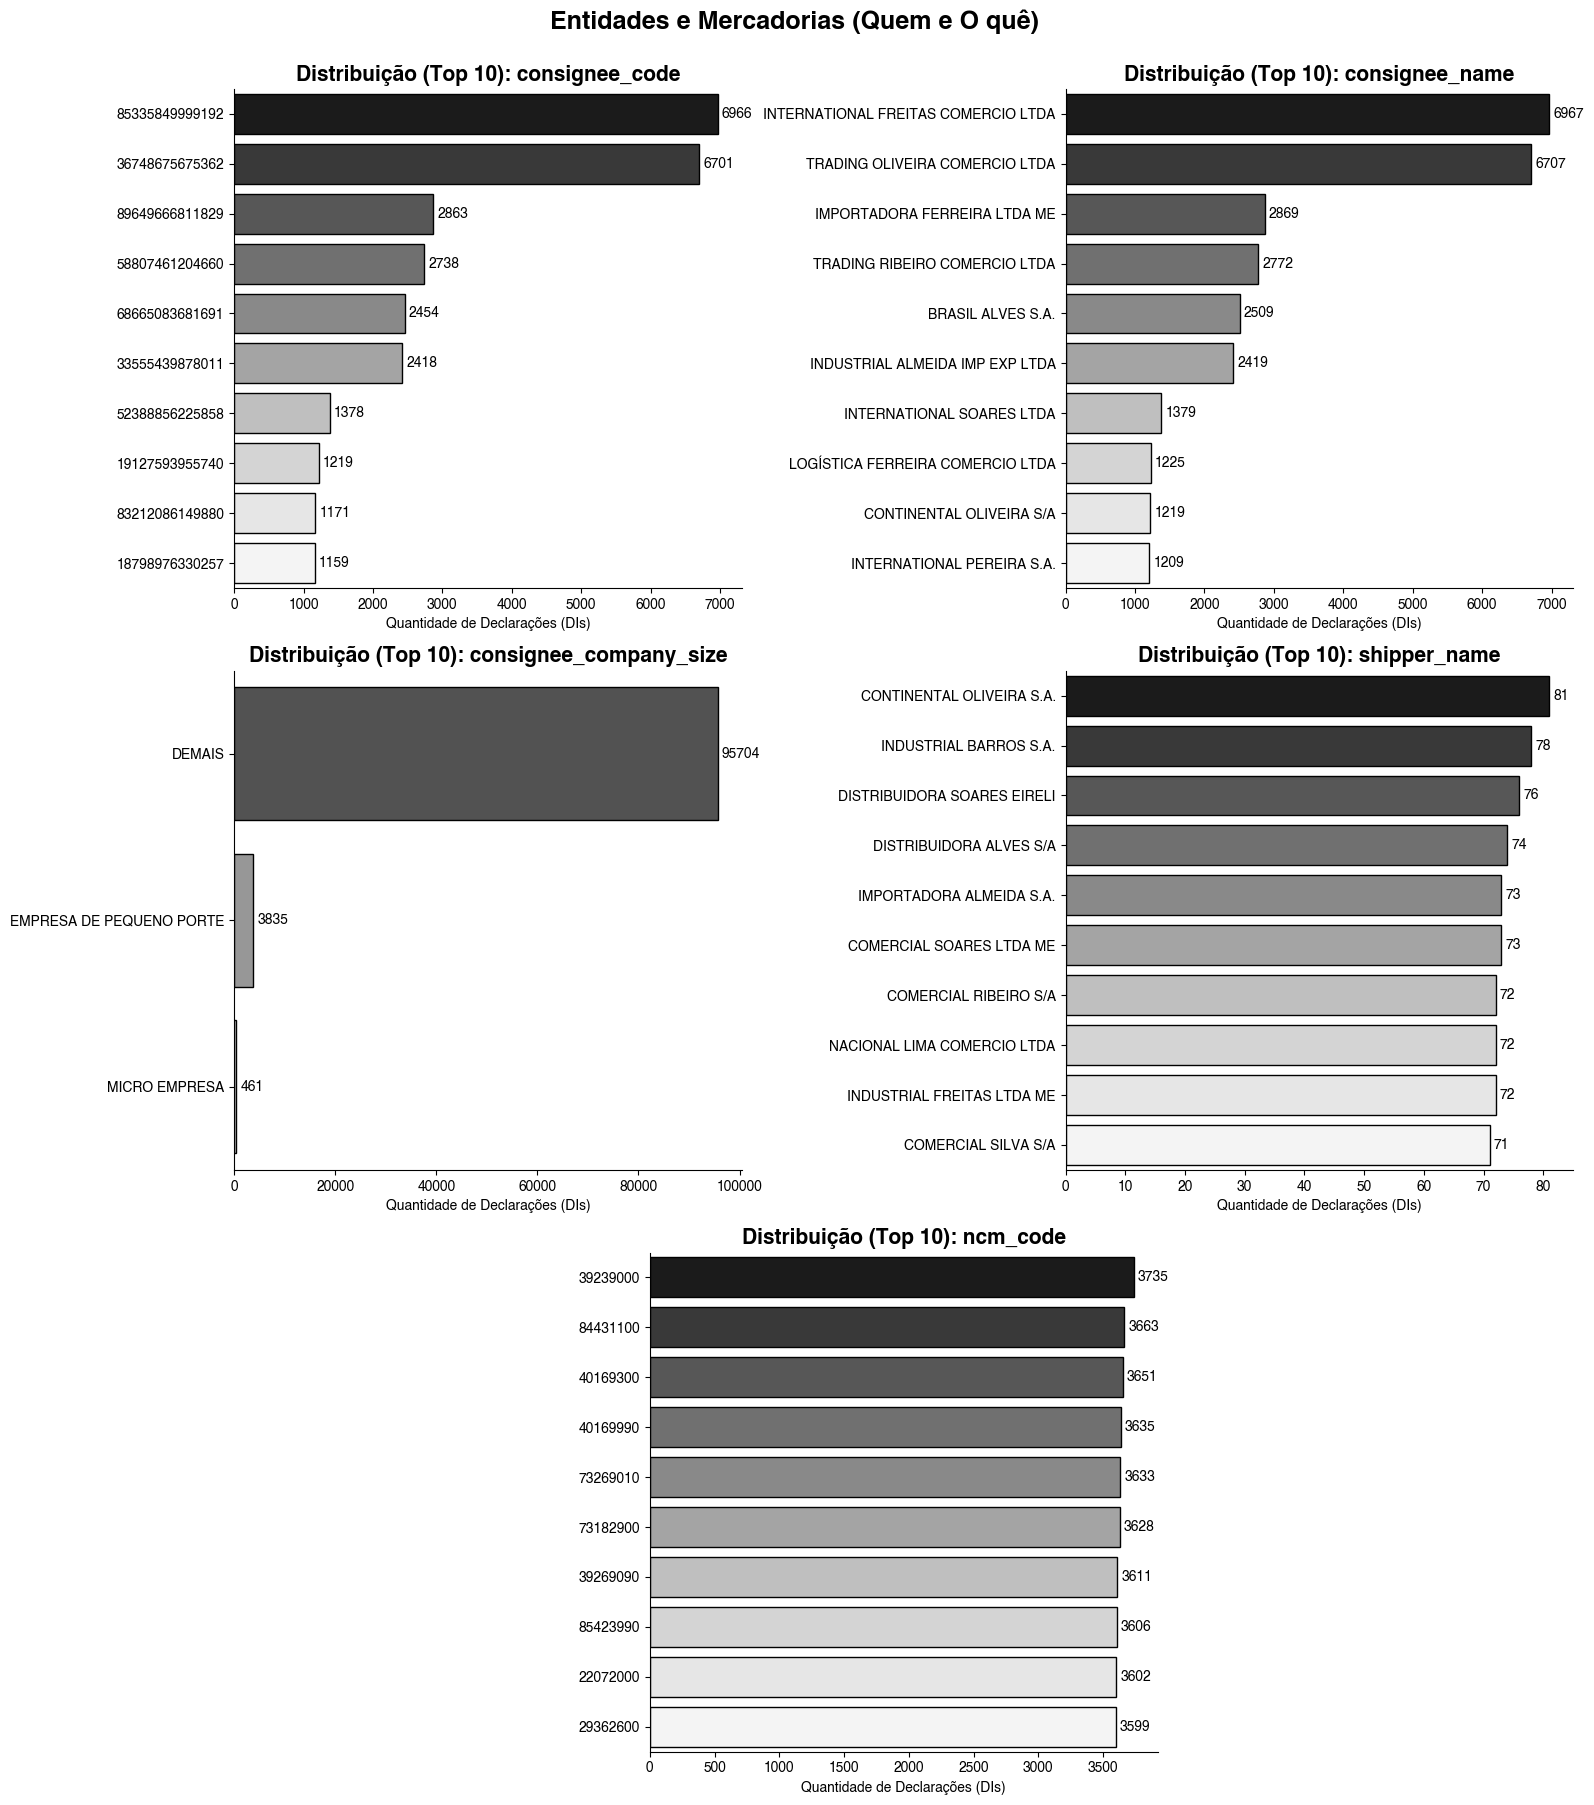

In [22]:
plotar_grupo_variaveis_avancado(grupo_entidades_mercadoria, 'Entidades e Mercadorias (Quem e O quê)')

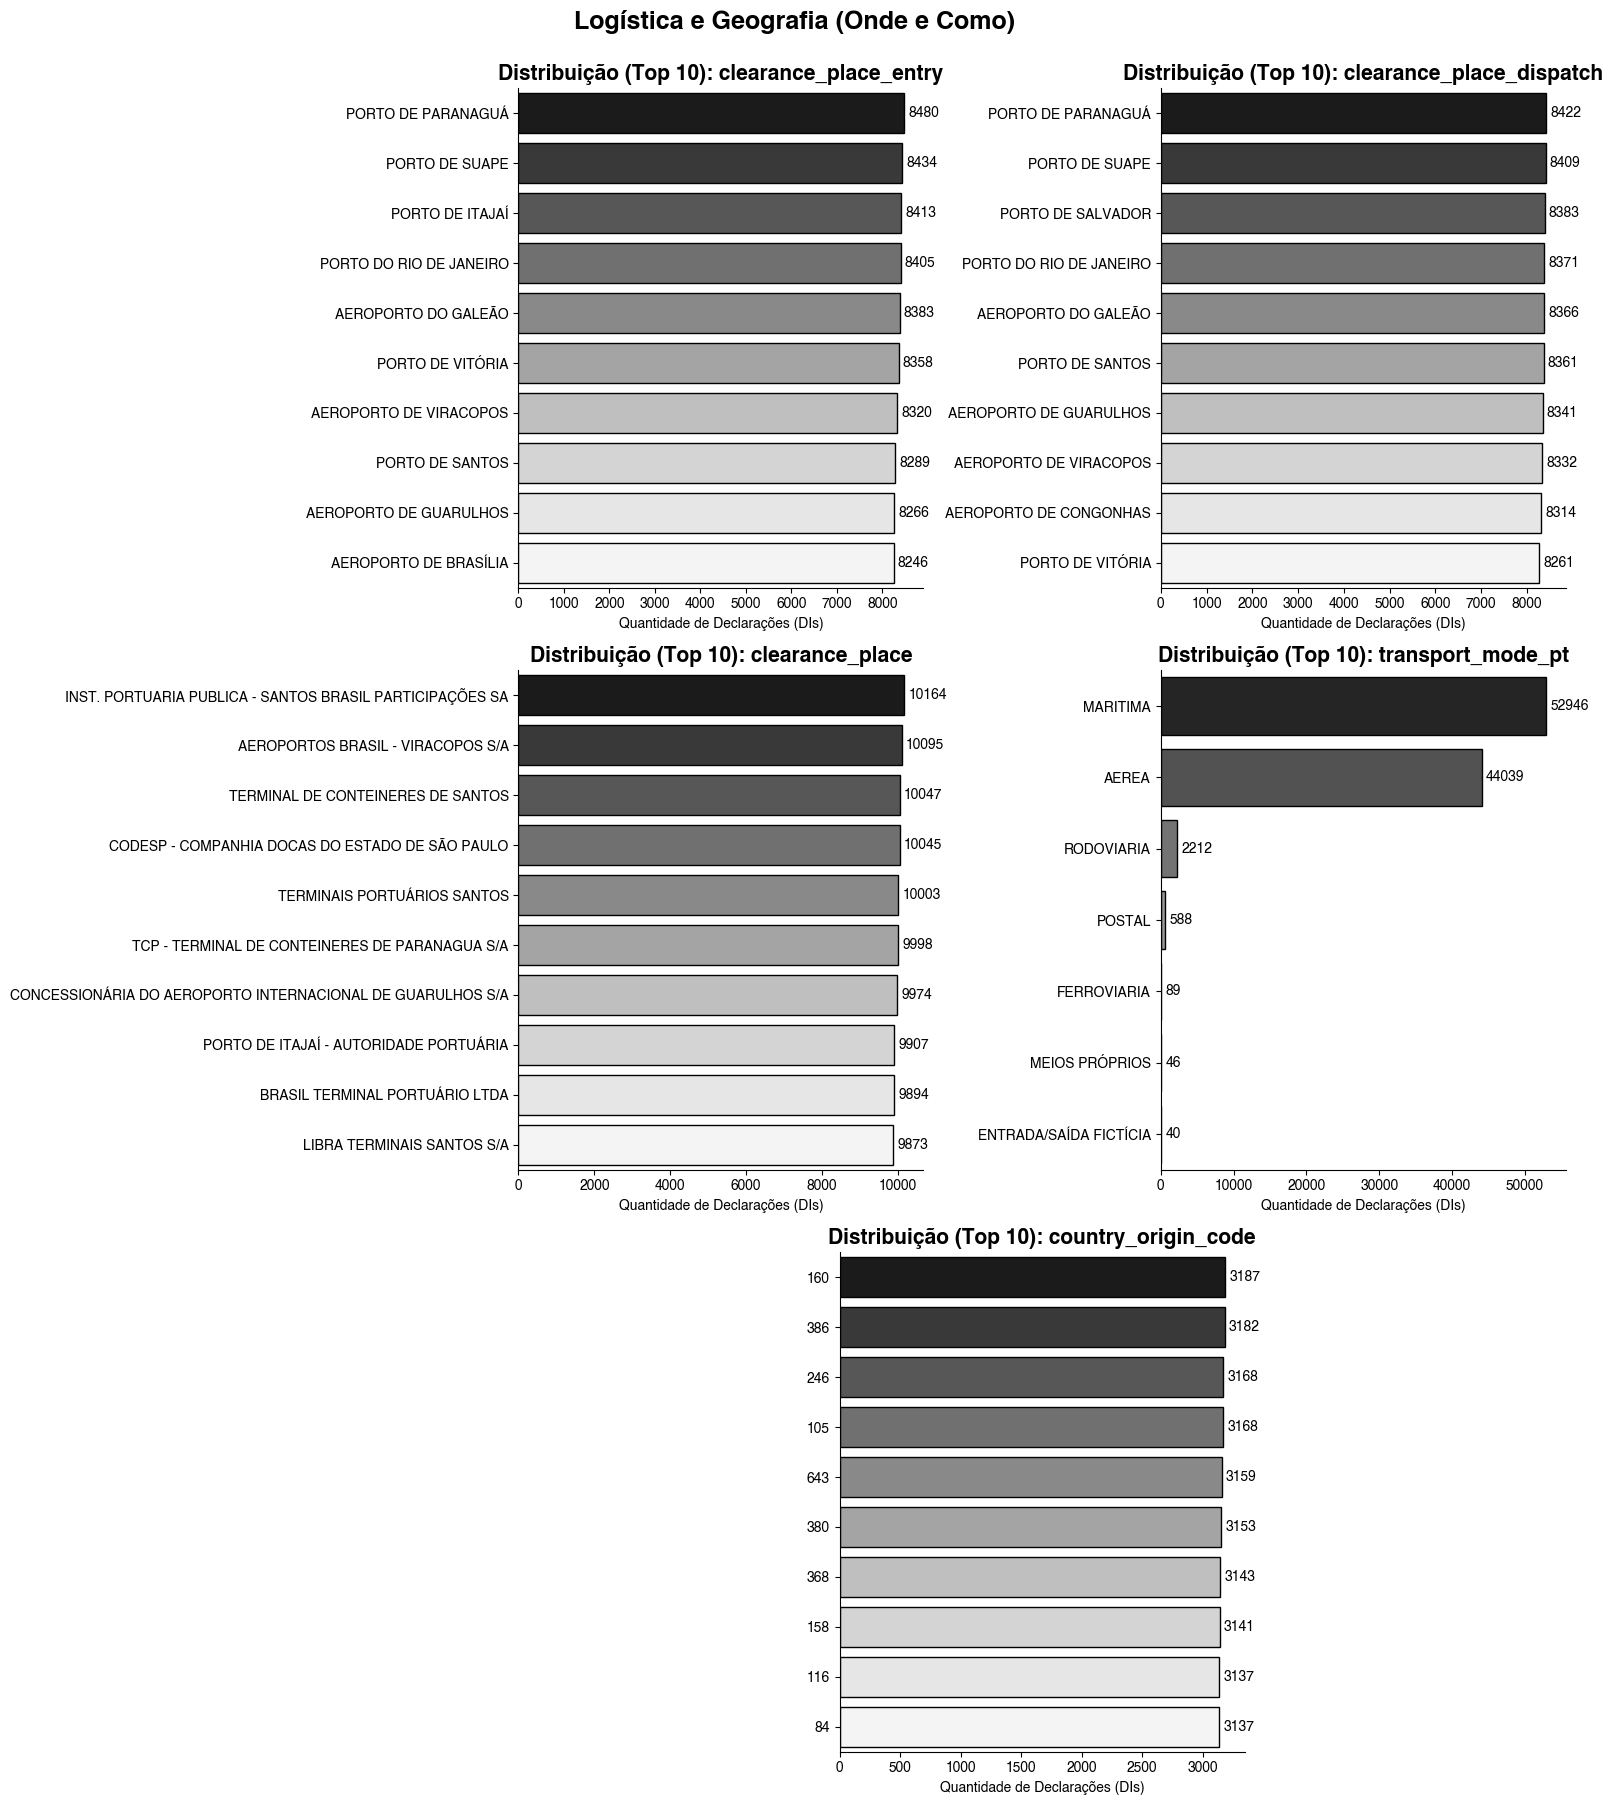

In [23]:
plotar_grupo_variaveis_avancado(grupo_logistica_geografia, 'Logística e Geografia (Onde e Como)')

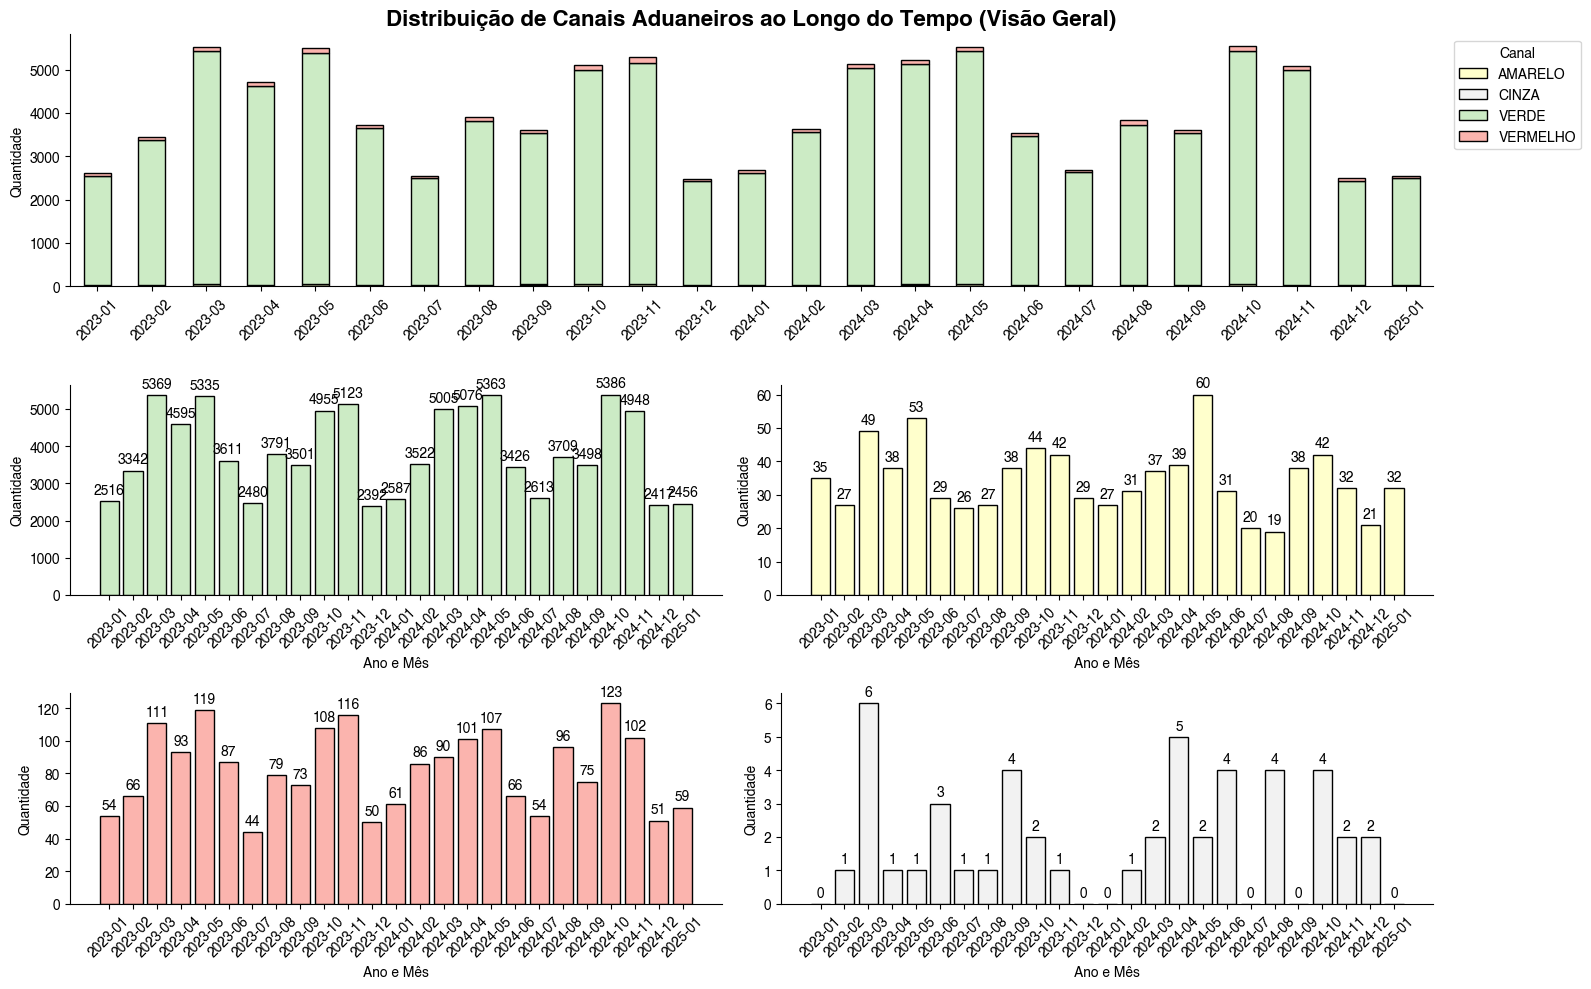

In [24]:
# Tabela cruzada: Mês x Canal
canal_por_mes = pd.crosstab(df['yearmonth'], df['channel'])
canais_presentes = [c for c in ['VERDE', 'AMARELO', 'VERMELHO', 'CINZA'] if c in canal_por_mes.columns]

# Cores específicas relacionadas aos canais
cores_canais = {'VERDE': '#ccebc5', 'AMARELO': '#ffffcc', 'VERMELHO': '#fbb4ae', 'CINZA': '#f2f2f2'}
cores_lista = [cores_canais.get(cor, '#cccccc') for cor in canal_por_mes.columns]

# -----------------------------------------------------------------------------
# Configurando o Grid Avançado (3 linhas x 2 colunas)
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1]) # Dá um pouco mais de altura ao gráfico principal

# 1. Gráfico Principal (Ocupando a linha 0 inteira, ou seja, as 2 colunas)
ax_main = fig.add_subplot(gs[0, :])

# Plotando o gráfico de barras empilhadas no ax_main
canal_por_mes.plot(kind='bar', stacked=True, edgecolor='k', color=cores_lista, ax=ax_main)

ax_main.set_title('Distribuição de Canais Aduaneiros ao Longo do Tempo (Visão Geral)', fontsize=16, fontweight='bold')
ax_main.set_xlabel('') # Deixamos em branco porque os gráficos de baixo já terão o label do mês
ax_main.set_ylabel('Quantidade')

# Formatando o eixo X do gráfico principal
ax_main.set_xticks(range(len(canal_por_mes.index)))
ax_main.set_xticklabels([x.strftime('%Y-%m') for x in canal_por_mes.index], rotation=45)
ax_main.legend(title='Canal', bbox_to_anchor=(1.01, 1), loc='upper left')

# Removendo bordas para manter a elegância
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)

# 2. Subplots Individuais (Distribuídos 2 a 2 nas linhas 1 e 2)
ax1 = fig.add_subplot(gs[1, 0]) # Linha 1, Coluna Esquerda
ax2 = fig.add_subplot(gs[1, 1]) # Linha 1, Coluna Direita
ax3 = fig.add_subplot(gs[2, 0]) # Linha 2, Coluna Esquerda
ax4 = fig.add_subplot(gs[2, 1]) # Linha 2, Coluna Direita

axes_secundarios = [ax1, ax2, ax3, ax4]

# Loop para preencher os 4 subplots
for ax, canal in zip(axes_secundarios, canais_presentes):
    # Plotando as barras para o canal específico
    bars = ax.bar(range(len(canal_por_mes.index)), canal_por_mes[canal], color=cores_canais[canal], edgecolor='k')
    
#     ax.set_title(f'Volume ao Longo do Tempo: Canal {canal}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade')
    ax.set_xlabel('Ano e Mês')
    
    # Adicionando os números em cima de cada barra
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
    
    # Formatando as bordas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Formatando o eixo X para cada subplot
    ax.set_xticks(range(len(canal_por_mes.index)))
    ax.set_xticklabels([x.strftime('%Y-%m') for x in canal_por_mes.index], rotation=45)

# Ajuste final de layout
plt.tight_layout()
plt.savefig(f'EDA_figs/dist_quantidade_por_canal.png', bbox_inches='tight', dpi=300)
plt.show()

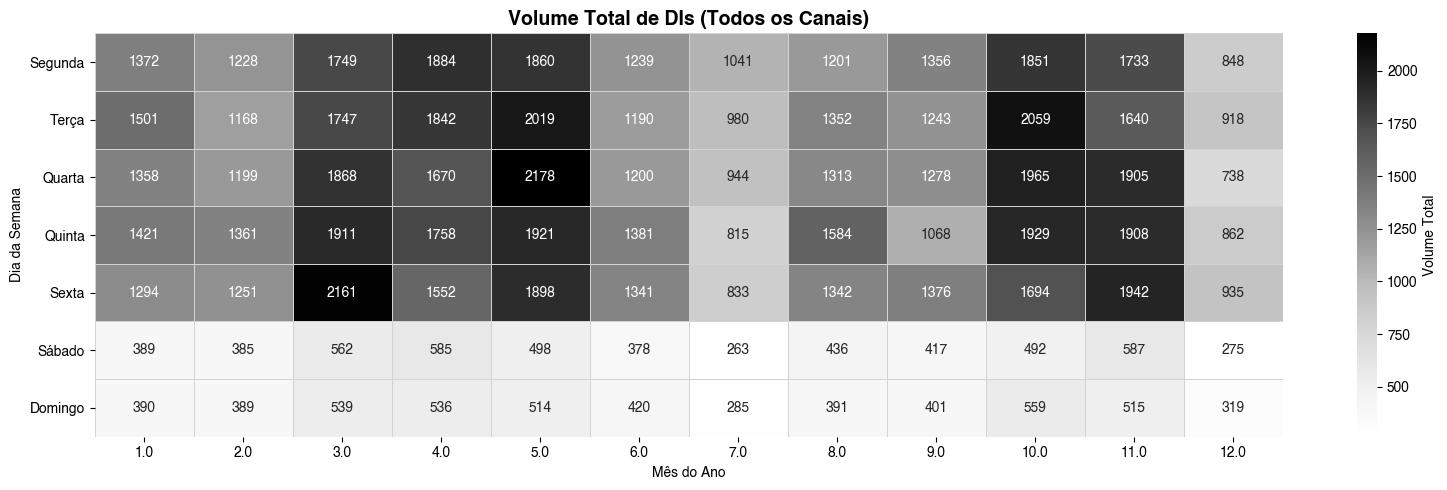

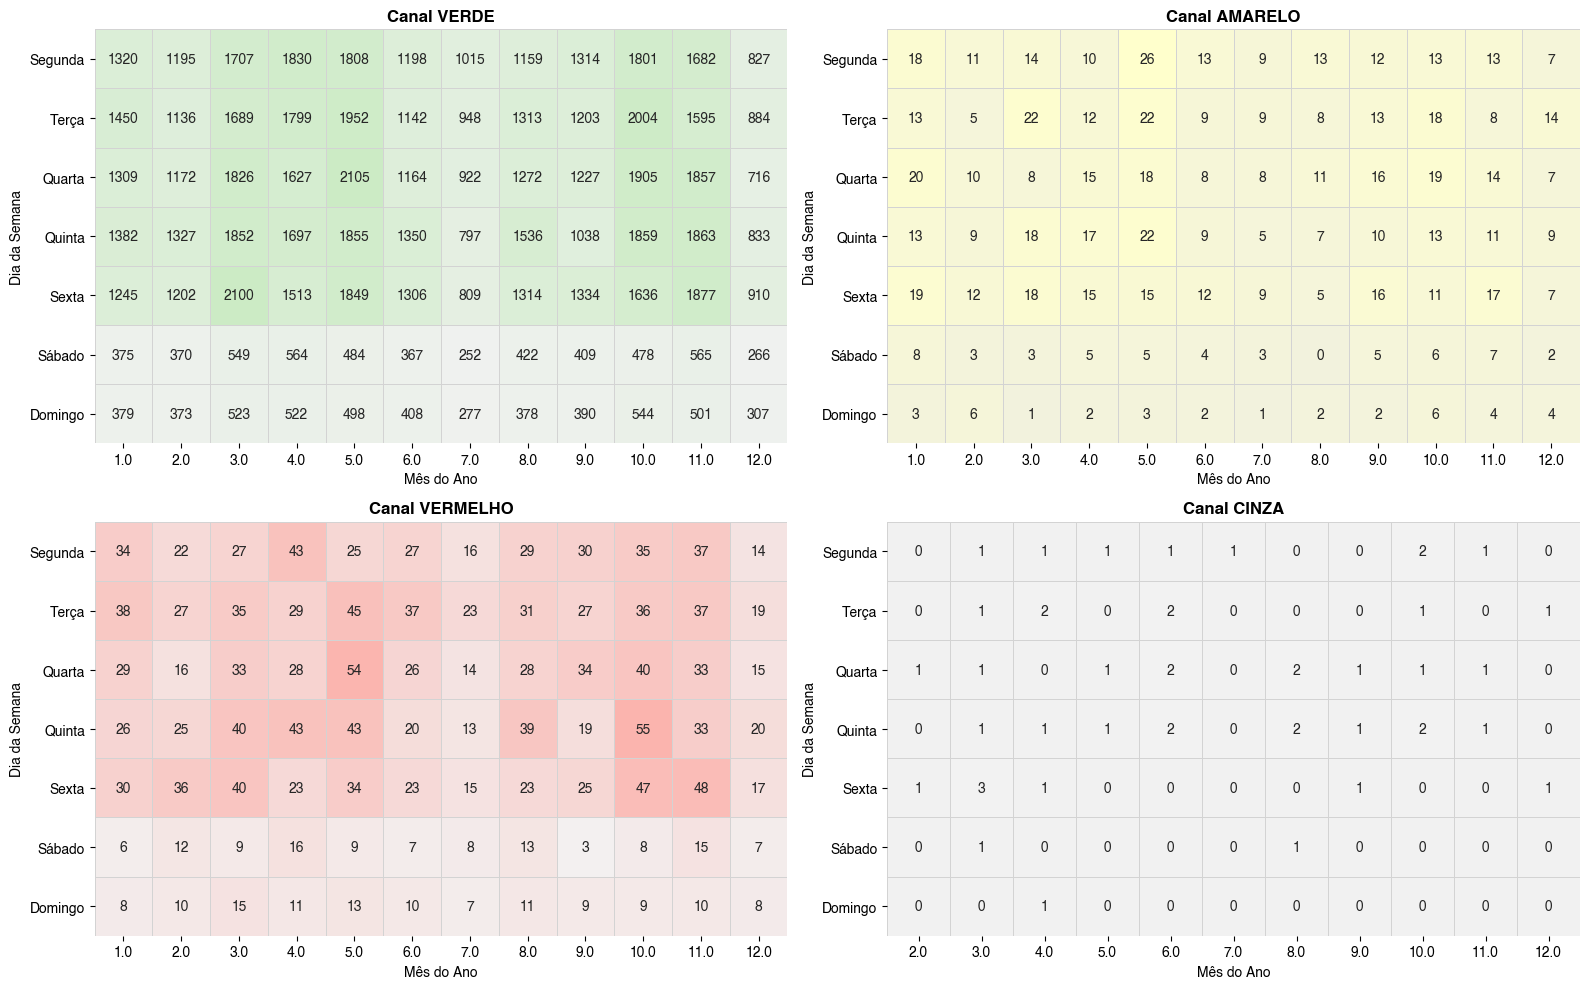

In [25]:
# Preparação dos dados temporais
df['dia_semana'] = df['registry_date'].dt.dayofweek
df['mes'] = df['registry_date'].dt.month

dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df['dia_semana_nome'] = df['dia_semana'].map(dias_map)
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# FIGURA 1: Heatmap TOTAL
fig_total, ax_total = plt.subplots(figsize=(16, 5))

heatmap_total = pd.crosstab(df['dia_semana_nome'], df['mes']).reindex(ordem_dias).fillna(0).astype(int)

# Plotando o Total com a paleta de cinzas para manter consistência
sns.heatmap(heatmap_total, annot=True, fmt="d", cmap="Greys", ax=ax_total, 
            cbar_kws={'label': 'Volume Total'}, linewidths=0.5, linecolor='lightgrey')
ax_total.set_title('Volume Total de DIs (Todos os Canais)', fontsize=14, fontweight='bold')
ax_total.set_ylabel('Dia da Semana')
ax_total.set_xlabel('Mês do Ano')

plt.tight_layout()
plt.savefig(f'EDA_figs/dist_semanal_total.png', bbox_inches='tight', dpi=300)
plt.show()

# FIGURA 2: Heatmaps por Canal
canais = ['VERDE', 'AMARELO', 'VERMELHO', 'CINZA']
cores_canais = {'VERDE': '#ccebc5', 'AMARELO': '#ffffcc', 'VERMELHO': '#fbb4ae', 'CINZA': '#f2f2f2'}

# Criando um grid 2x2 para os 4 canais
fig_canais, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_canais = axes.flatten() # Transforma a matriz 2x2 numa lista simples para iterar

for ax, canal in zip(axes_canais, canais):
    # Filtra os dados apenas para o canal atual
    df_canal = df[df['channel'] == canal]
    heatmap_canal = pd.crosstab(df_canal['dia_semana_nome'], df_canal['mes']).reindex(ordem_dias).fillna(0).astype(int)
    
    # Criando um gradiente (colormap) que vai do branco até a cor exata do dicionário
    cmap_canal = sns.light_palette(cores_canais[canal], as_cmap=True)
    
    # Usando linewidths e linecolor para garantir legibilidade das células mais claras
    sns.heatmap(heatmap_canal, annot=True, fmt="d", cmap=cmap_canal, ax=ax, 
                cbar=False, linewidths=0.5, linecolor='lightgrey')
    
    ax.set_title(f'Canal {canal}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dia da Semana')
    ax.set_xlabel('Mês do Ano')

plt.tight_layout()
plt.savefig(f'EDA_figs/dist_semanal_por_canal.png', bbox_inches='tight', dpi=300)
plt.show()

# Limpando as colunas temporárias para não poluir o dataset original
df.drop(columns=['dia_semana', 'mes', 'dia_semana_nome'], inplace=True, errors='ignore')

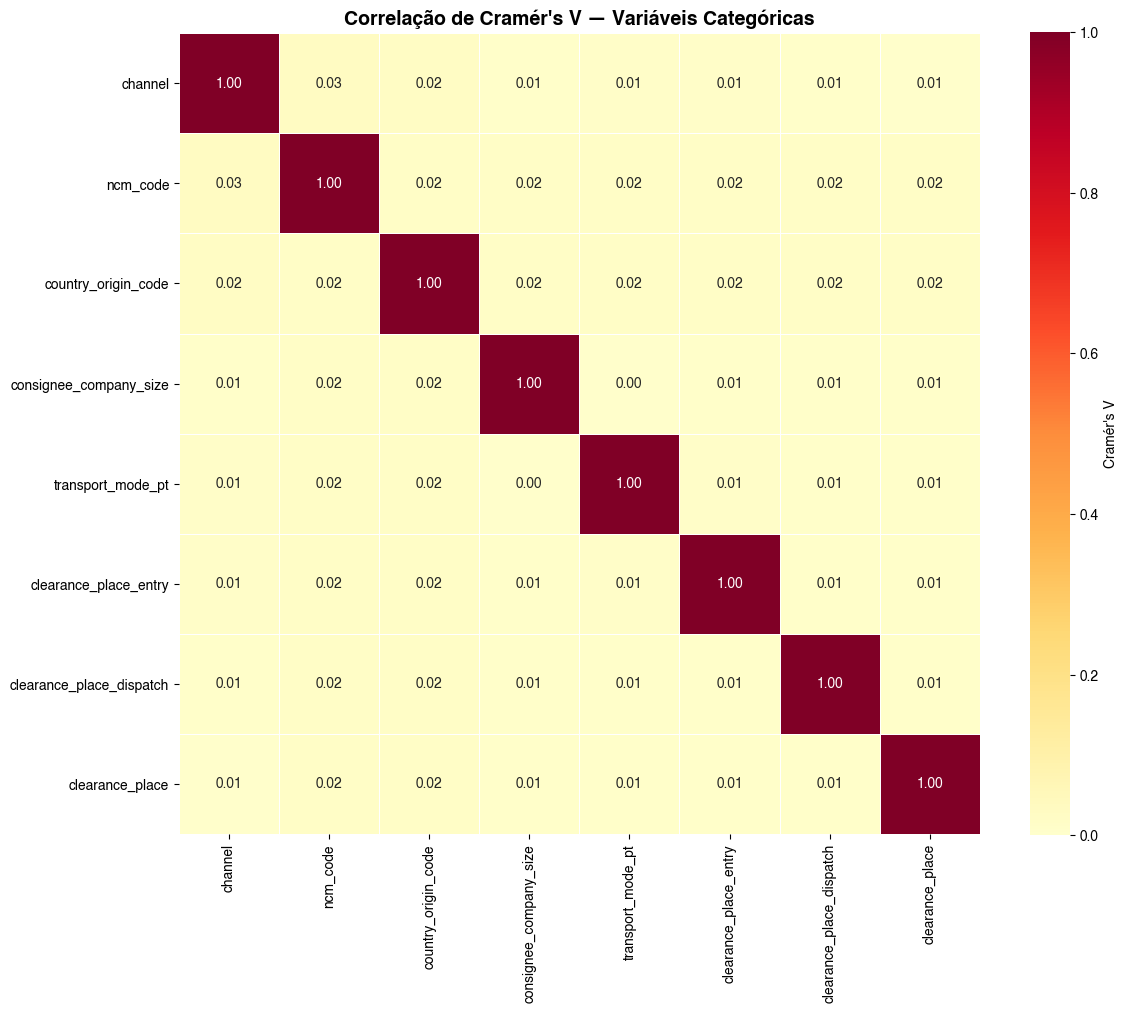

In [26]:
"""
Heatmap de Correlação de Cramér's V para variáveis categóricas.
"""

def cramers_v(x, y):
    """Calcula o Cramér's V entre duas variáveis categóricas."""
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0

cat_cols = [
    'channel', 'ncm_code', 'country_origin_code',
    'consignee_company_size', 'transport_mode_pt',
    'clearance_place_entry', 'clearance_place_dispatch',
    'clearance_place',
]

# Preenchendo NaN para evitar erro no crosstab
df[cat_cols] = df[cat_cols].fillna('MISSING')

# Matriz de Cramér's V
n = len(cat_cols)
matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        v = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
        matrix[i, j] = matrix[j, i] = v

cv_df = pd.DataFrame(matrix, index=cat_cols, columns=cat_cols)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cv_df, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': "Cramér's V"})
plt.title("Correlação de Cramér's V — Variáveis Categóricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_figs/cramers_v_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Quais são os 5 NCMs com maior risco de canal vermelho? Apresente uma análise detalhada.

In [27]:
tabela_proporcao = pd.crosstab(df['ncm_code'], df['channel'], normalize='index') * 100

# Retornar as 5 categorias com a MAIOR PERCENTAGEM de Canal Vermelho
tabela_proporcao['VERMELHO'].sort_values(ascending=False).head(5).round(2)

ncm_code
38220090    3.99
22072000    3.58
22071000    3.24
85444200    2.62
40169990    2.37
Name: VERMELHO, dtype: float64

### Existe sazonalidade na distribuição dos canais? Como isso pode impactar o modelo?

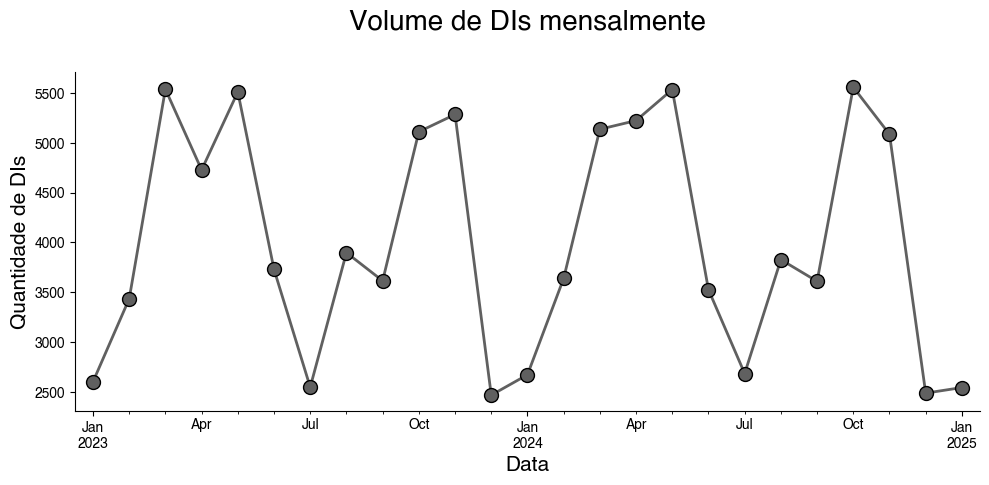

In [30]:
f, ax = plt.subplots(figsize=(10, 5))
# Agrupar por mês e contar quantas DIs existem
volume_mensal = df.groupby('yearmonth').size()

# Plotar gráfico de linha para ver a tendência
volume_mensal.plot(kind='line', marker='o', color='#606060', linewidth=2, ax = ax, markeredgecolor='k', markersize = 10)

ax.set_title('Volume de DIs mensalmente', fontsize = 20, y = 1.1)
ax.set_xlabel('Data', fontsize = 15)
ax.set_ylabel('Quantidade de DIs', fontsize = 15)

# Arrumando o limite de x
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin - 0.5, xmax + 0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'EDA_figs/serie_temporal.png', bbox_inches='tight', dpi=300)
plt.show()

A série temporal revela uma clara sazonalidade. Observamos quedas drásticas no volume de importações (vales de ~2.500 DIs) nos meses de Janeiro e Julho. Em contrapartida, os portos sofrem picos de sobrecarga em torno de abril e outubro.

### Qual o impacto do modo de transporte na seleção do canal? Justifique com dados.

In [23]:
# Normalizando por linha (index) para ver a % dentro de cada modal
impacto_transporte = pd.crosstab(df['transport_mode_pt'], df['channel'], normalize='index') * 100

# Arredondando e preenchendo nulos com 0
impacto_transporte = impacto_transporte.round(2).fillna(0)
print("\nTaxa de incidência (%) de cada canal por Modal de Transporte:")
print(impacto_transporte[['VERDE', 'AMARELO', 'VERMELHO', 'CINZA']].to_string())


Taxa de incidência (%) de cada canal por Modal de Transporte:
channel                 VERDE  AMARELO  VERMELHO  CINZA
transport_mode_pt                                      
AEREA                   96.59     0.92      2.44   0.05
ENTRADA/SAÍDA FICTÍCIA  97.50     2.50      0.00   0.00
FERROVIARIA             98.88     0.00      1.12   0.00
MARITIMA                97.35     0.82      1.79   0.04
MEIOS PRÓPRIOS          97.83     0.00      2.17   0.00
POSTAL                  97.11     0.85      2.04   0.00
RODOVIARIA              97.29     1.08      1.58   0.05


### Como o porte da empresa importadora influencia o canal selecionado?

In [ ]:
impacto_porte = pd.crosstab(df['consignee_company_size'], df['channel'], normalize='index') * 100
impacto_porte = impacto_porte.round(1)

print("\nTaxa de incidência (%) de cada canal por Tamanho da Empresa:")
# Reordenando para fazer sentido de negócio (Menor para o Maior, se existirem)
ordem_porte = ['MICRO EMPRESA', 'EMPRESA DE PEQUENO PORTE', 'DEMAIS']
ordem_existente = [p for p in ordem_porte if p in impacto_porte.index]

if ordem_existente:
    print(impacto_porte.loc[ordem_existente, ['VERDE', 'AMARELO', 'VERMELHO', 'CINZA']].to_string())
else:
    print(impacto_porte.to_string())

# Limpeza da coluna temporária
df.drop(columns=['mes_temp'], inplace=True, errors='ignore')


Taxa de incidência (%) de cada canal por Tamanho da Empresa:
channel                   VERDE  AMARELO  VERMELHO  CINZA
consignee_company_size                                   
MICRO EMPRESA              95.7      1.3       2.8    0.2
EMPRESA DE PEQUENO PORTE   96.1      1.1       2.8    0.0
DEMAIS                     97.1      0.9       2.0    0.0
